# Telecom Customer Churn - End-to-End Analysis

This notebook demonstrates the complete machine learning pipeline used for the Telecom Customer Churn Prediction project. It serves as a comprehensive data science report showcasing data cleaning, exploratory data analysis (EDA), feature engineering, model training, evaluation, and explainability.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Ensure the project root is on the Python path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from src.config import DATASET_PATH
from src.data_processing import load_dataset, clean_dataset, encode_target
from src.feature_engineering import engineer_features

%matplotlib inline
sns.set_theme(style='whitegrid')

## 1. Data Loading and Cleaning
We begin by loading the raw dataset. The `clean_dataset` function handles known issues such as blank values in the `TotalCharges` column (which are coerced to numeric and imputed with the median) and standardises categorical columns.

In [2]:
df_raw = load_dataset(DATASET_PATH)
df_clean = clean_dataset(df_raw)
display(df_clean.head())
print(f"Cleaned dataset shape: {df_clean.shape}")

2026-06-27 22:04:51 | src.data_processing  | INFO    | Loading dataset from /Applications/Projects/my-personal-projects/COM763-ass1-streamlit-and-ass2/client2/Customer-Churn-Prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-06-27 22:04:51 | src.data_processing  | INFO    | Loaded 7043 rows, 21 columns
2026-06-27 22:04:51 | src.data_processing  | INFO    | Converted SeniorCitizen to categorical (No/Yes)
2026-06-27 22:04:51 | src.data_processing  | INFO    | Imputed 11 missing TotalCharges values with median (1397.47)
2026-06-27 22:04:51 | src.data_processing  | INFO    | Cleaning complete. Final shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cleaned dataset shape: (7043, 21)


## 2. Exploratory Data Analysis (EDA)
Let's explore some key relationships in the data before engineering new features. We will look at how Tenure, Monthly Charges, and Contract Type relate to Churn.

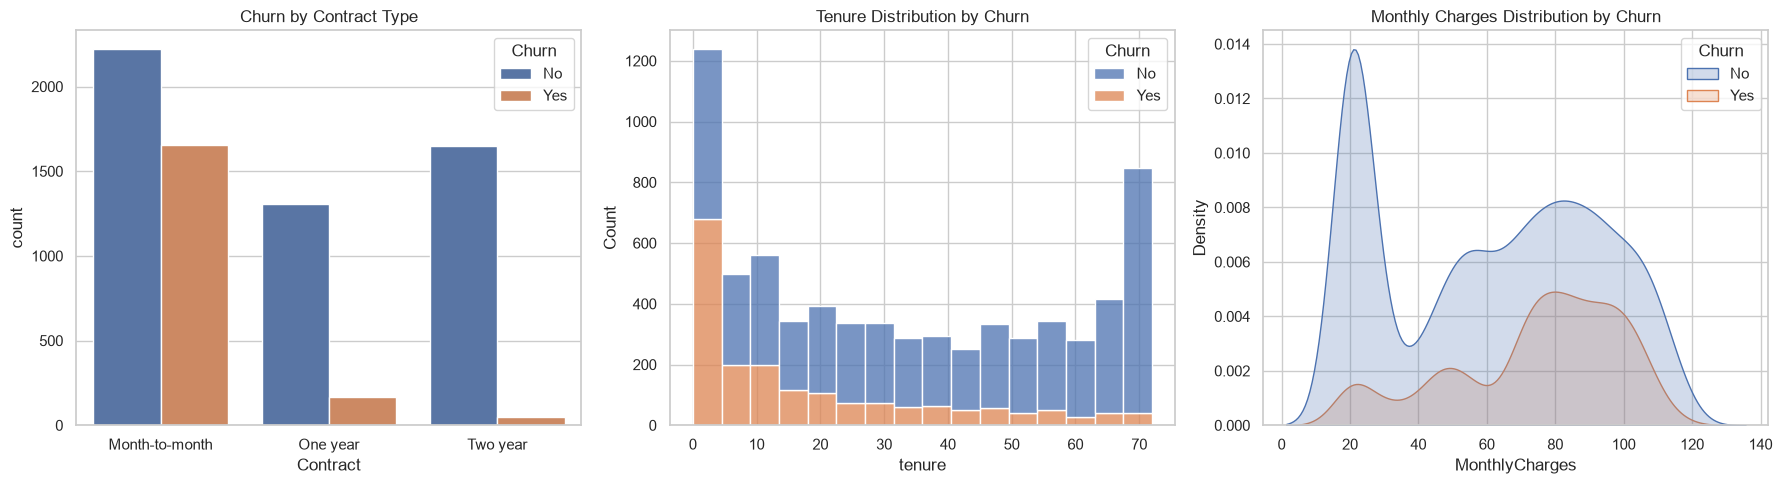

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Churn by Contract Type
sns.countplot(data=df_clean, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Churn by Contract Type')

# Plot 2: Distribution of Tenure by Churn
sns.histplot(data=df_clean, x='tenure', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn')

# Plot 3: Distribution of Monthly Charges by Churn
sns.kdeplot(data=df_clean, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[2])
axes[2].set_title('Monthly Charges Distribution by Churn')

plt.tight_layout()
plt.show()

## 3. Feature Engineering
Based on the EDA and domain knowledge, we engineer several features to help the model:
- **TenureGroup**: Binning tenure into logical phases (e.g., New, Loyal).
- **AverageMonthlySpend**: `TotalCharges` / `tenure`.
- **IsMonthToMonthContract**: A binary indicator for high-risk contracts.
- **Service groupings**: Aggregating security and streaming services.

In [4]:
df_eng = engineer_features(df_clean)
df_final = encode_target(df_eng)
display(df_final[['TenureGroup', 'AverageMonthlySpend', 'IsMonthToMonthContract']].head())
print(f"Final shape after feature engineering: {df_final.shape}")

2026-06-27 22:04:52 | src.feature_engineering | INFO    | Engineered 7 features
2026-06-27 22:04:52 | src.data_processing  | INFO    | Target encoded — Churn=1: 1869 (26.5%), Churn=0: 5174 (73.5%)


,TenureGroup,AverageMonthlySpend,IsMonthToMonthContract
0,New,29.850000,Yes
1,Established,55.573529,No
2,New,54.075000,Yes
3,Established,40.905556,No
4,New,75.825000,Yes


Final shape after feature engineering: (7043, 28)


## 4. Model Training Pipeline
We use an `imblearn` pipeline to safely apply **SMOTE** (Synthetic Minority Over-sampling Technique) only on the training folds. This prevents data leakage that would artificially inflate validation performance. We will train a **Logistic Regression** model, which proved to be the best performing model in our full evaluation.

In [5]:
# Separate features and target
X = df_final.drop(columns=["customerID", "Churn"])
y = df_final["Churn"]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

# Create pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 5. Model Evaluation
We evaluate the model on the unseen test set, focusing on the **F1-Score** and **Recall** for the minority churn class.

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



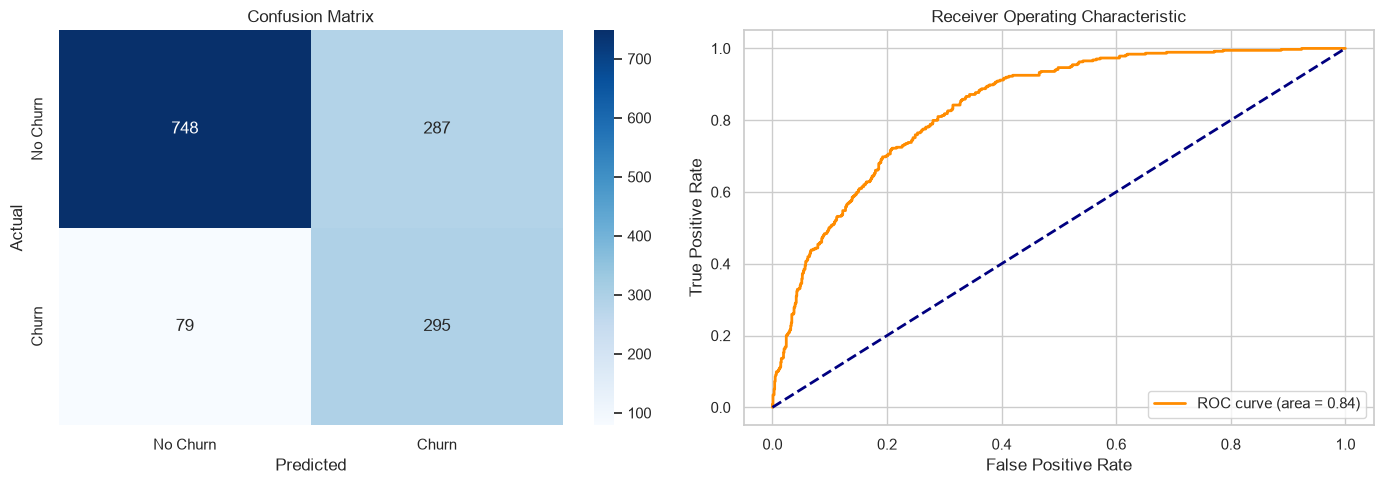

In [6]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6. Model Explainability (SHAP)
To understand *why* the model makes its predictions, we use SHAP (SHapley Additive exPlanations). We'll plot a global summary to see the top driving features.

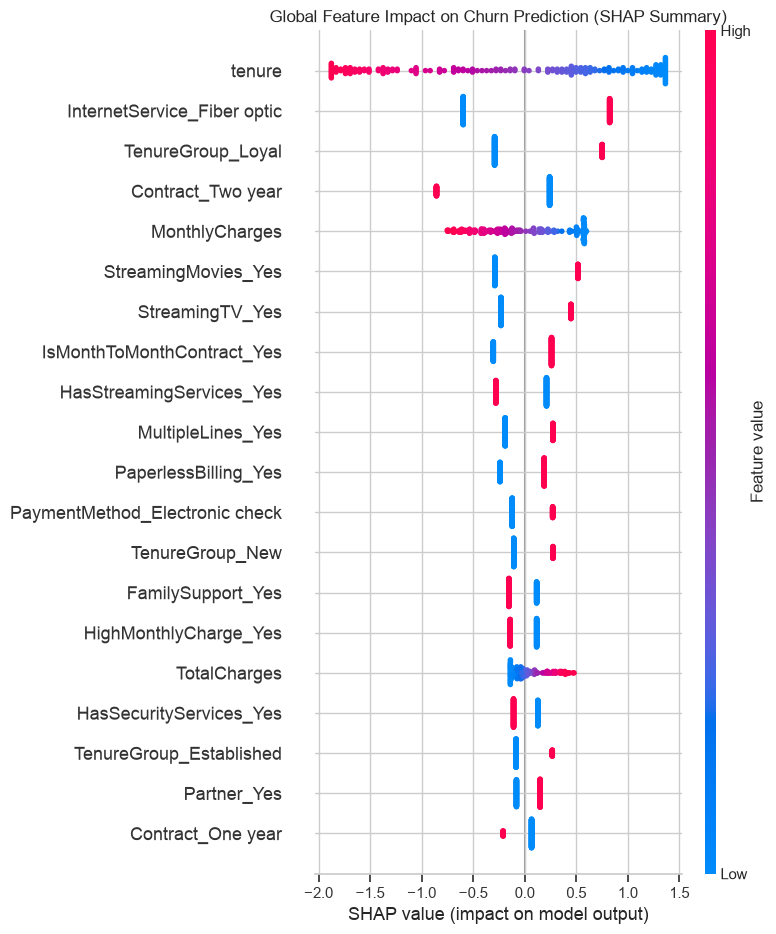

In [7]:
# Extract preprocessor and feature names
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["classifier"]

X_test_transformed = preprocessor.transform(X_test)
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features)

# Use a sample of 200 to speed up SHAP computation in the notebook
X_sample = X_test_transformed[:200]
explainer = shap.LinearExplainer(model, X_test_transformed)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=all_features, show=False)
plt.title("Global Feature Impact on Churn Prediction (SHAP Summary)")
plt.tight_layout()
plt.show()